In [ ]:
# =====================
# CELL 1: Install Dependencies
# =====================
!pip install -q faiss-cpu tqdm scikit-learn matplotlib seaborn timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.8 MB/s eta 0:00:00


In [ ]:
# =====================
# CELL 2: Imports
# =====================
import os, random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import faiss
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    precision_score, recall_score, classification_report
)
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore", message=".*lr_scheduler.step.*")

In [ ]:
# =====================
# CELL 3: Global Config
# =====================
import torch # Added to resolve NameError

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 9  # Reduced from 10 after removing trash class
EPOCHS = 25
SEED = 42
FEAT_DIM = 768  # DINOv2 ViT-B/14 output dimension

FEATS_PATH  = "/content/drive/MyDrive/Colab Notebooks/Uploads/train_feats_dinov2_9cls.npy"
LABELS_PATH = "/content/drive/MyDrive/Colab Notebooks/Uploads/train_labels_dinov2_9cls.npy"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Device:", DEVICE)
print("Feature Dimension:", FEAT_DIM)
print("Number of Classes:", NUM_CLASSES)

Device: cuda
Feature Dimension: 768
Number of Classes: 9


In [ ]:
# =====================
# CELL 4: Mount Google Drive
# =====================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =====================
# CELL 5: Load Raw Dataset
# =====================
RAW_DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/archive/garbage_classification"

if not os.path.exists(RAW_DATASET_ROOT):
    raise FileNotFoundError(f"Raw dataset path not found: {RAW_DATASET_ROOT}")

raw_ds = ImageFolder(RAW_DATASET_ROOT)

print("Raw dataset found")
print("Original classes:")
for i, cls in enumerate(raw_ds.classes):
    print(f"{i:2d} : {cls}")
print("Total raw images:", len(raw_ds))

Raw dataset found
Original classes:
 0 : battery
 1 : biological
 2 : brown-glass
 3 : cardboard
 4 : clothes
 5 : green-glass
 6 : metal
 7 : paper
 8 : plastic
 9 : shoes
10 : trash
11 : white-glass
Total raw images: 15540


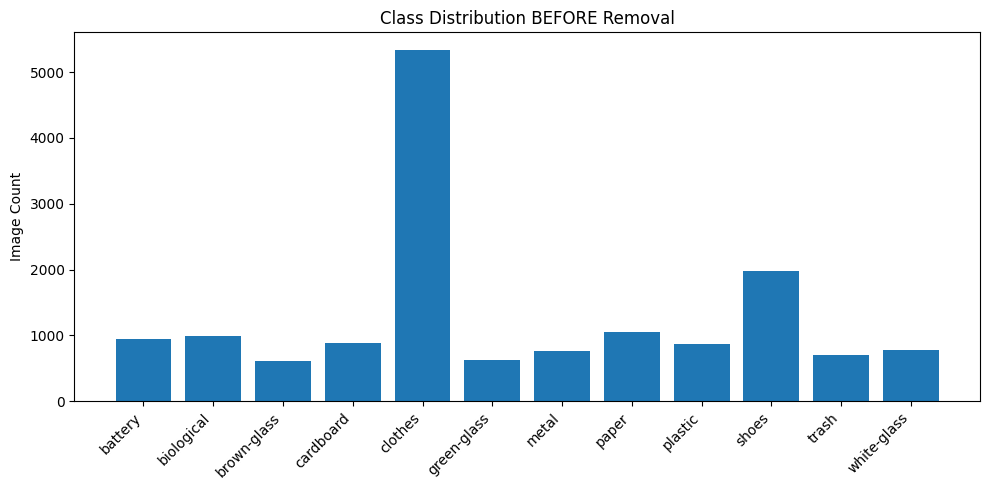

In [ ]:
# =====================
# CELL 6: Class Distribution BEFORE Filtering
# =====================
from collections import Counter

counts = Counter(raw_ds.targets)

plt.figure(figsize=(10,5))
plt.bar(raw_ds.classes, [counts[i] for i in range(len(raw_ds.classes))])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution BEFORE Removal")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

In [ ]:
# =====================
# CELL 7: Filter to 9 Classes (remove brown-glass, green-glass & trash)
# =====================
REMOVED_CLASSES = ["brown-glass", "green-glass", "trash"]

FINAL_CLASSES = [
    "plastic", "paper", "metal", "clothes", "shoes",
    "biological", "white-glass", "cardboard", "battery"
]

class_to_new_idx = {cls: i for i, cls in enumerate(FINAL_CLASSES)}

filtered_samples = []
for path, label in raw_ds.samples:
    cls_name = raw_ds.classes[label]
    if cls_name in FINAL_CLASSES:
        filtered_samples.append((path, class_to_new_idx[cls_name]))

print("Removed classes :", REMOVED_CLASSES)
print("Final classes   :", FINAL_CLASSES)
print("Images after filtering:", len(filtered_samples))

Removed classes : ['brown-glass', 'green-glass', 'trash']
Final classes   : ['plastic', 'paper', 'metal', 'clothes', 'shoes', 'biological', 'white-glass', 'cardboard', 'battery']
Images after filtering: 13601


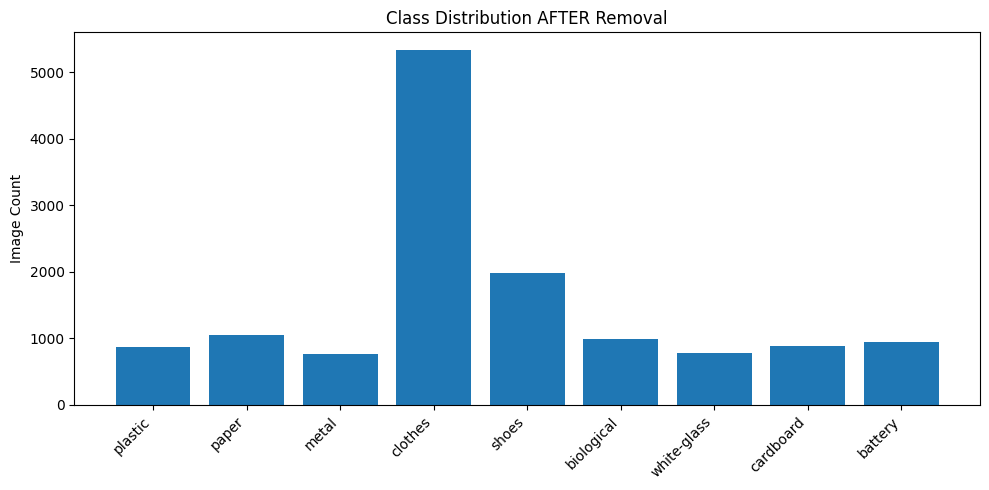


Per-class counts:
  plastic        : 865
  paper          : 1050
  metal          : 769
  clothes        : 5336
  shoes          : 1977
  biological     : 985
  white-glass    : 783
  cardboard      : 891
  battery        : 945


In [ ]:
# =====================
# CELL 8: Class Distribution AFTER Filtering
# =====================
filtered_labels = [y for _, y in filtered_samples]
counts_filtered = Counter(filtered_labels)

x = np.arange(len(FINAL_CLASSES))
y_vals = [counts_filtered[i] for i in range(len(FINAL_CLASSES))]

plt.figure(figsize=(10, 5))
plt.bar(x, y_vals)
plt.xticks(x, FINAL_CLASSES, rotation=45, ha="right")
plt.title("Class Distribution AFTER Removal")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

print("\nPer-class counts:")
for i, cls in enumerate(FINAL_CLASSES):
    print(f"  {cls:15s}: {counts_filtered[i]}")

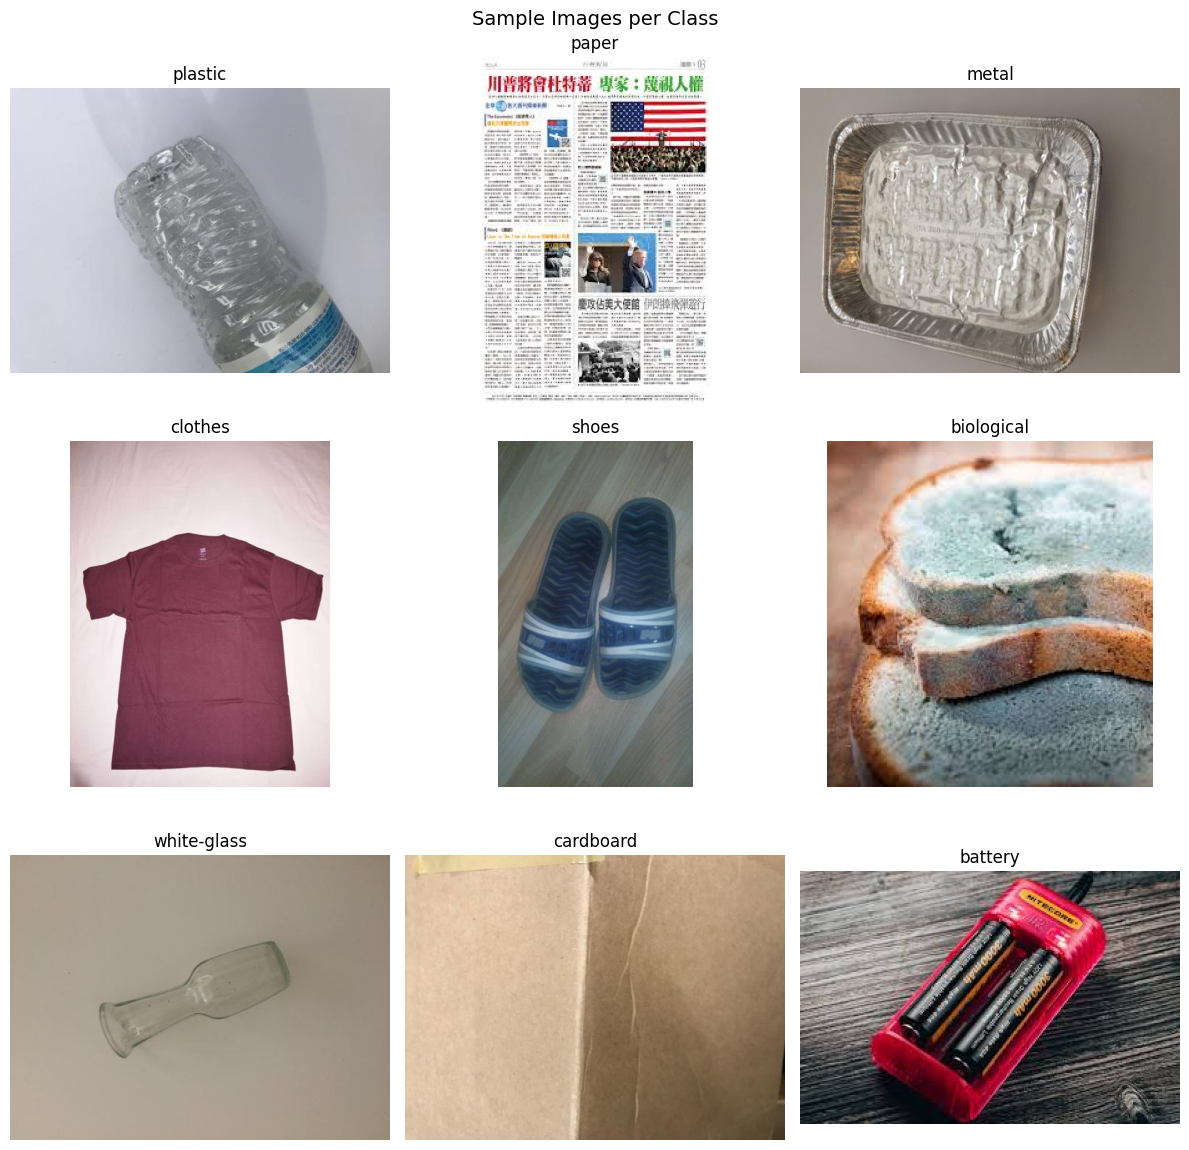

In [ ]:
# =====================
# CELL 9: Sample Images per Class
# =====================
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, cls in enumerate(FINAL_CLASSES):
    class_dir = os.path.join(RAW_DATASET_ROOT, cls)
    if os.path.exists(class_dir) and os.listdir(class_dir):
        img_name = os.listdir(class_dir)[0]
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls)
        axes[idx].axis("off")
    else:
        axes[idx].set_title(f"{cls} (no images)")
        axes[idx].axis("off")

plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

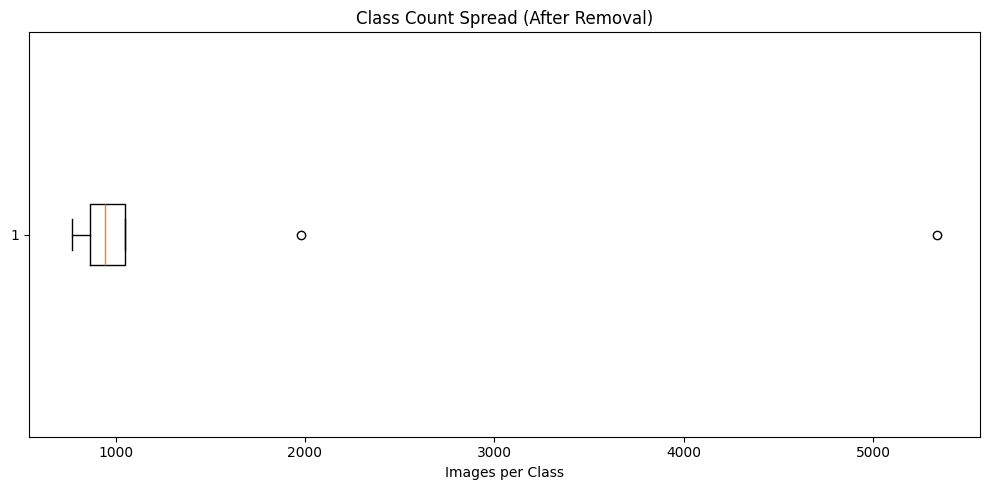

In [ ]:
# =====================
# CELL 10: Class Count Spread (Boxplot)
# =====================
plt.figure(figsize=(10, 5))
plt.boxplot([counts_filtered[i] for i in range(NUM_CLASSES)], vert=False)
plt.title("Class Count Spread (After Removal)")
plt.xlabel("Images per Class")
plt.tight_layout()
plt.show()

In [ ]:
# =====================
# CELL 11: Train / Val / Test Split (80 / 10 / 10)
# =====================
train_samples, remaining_samples = train_test_split(
    filtered_samples,
    test_size=0.2,
    stratify=filtered_labels,
    random_state=SEED
)

val_samples, test_samples = train_test_split(
    remaining_samples,
    test_size=0.5,
    stratify=[y for _, y in remaining_samples],
    random_state=SEED
)

print("Train samples:", len(train_samples))
print("Val samples  :", len(val_samples))
print("Test samples :", len(test_samples))

Train samples: 10880
Val samples  : 1360
Test samples : 1361


In [ ]:
# =====================
# CELL 12: Data Transforms
# =====================
train_tfms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.93, 1.0)),
    T.RandomHorizontalFlip(0.5),
    T.ColorJitter(brightness=0.07, contrast=0.07, saturation=0.06, hue=0.02),
    T.RandomAffine(degrees=3, translate=(0.02, 0.02), scale=(0.97, 1.03), shear=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Transforms defined")

Transforms defined


In [ ]:
# =====================
# CELL 13: Custom Dataset
# =====================
class FilteredDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# =====================
# CELL 14: DINOv2 ViT-B/14 Feature Extractor (frozen backbone)
# =====================
class DINOv2Encoder(nn.Module):
    """
    DINOv2 ViT-B/14 as frozen feature extractor.
    Output dimension: 768
    """
    def __init__(self):
        super().__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            return self.backbone(x)

encoder = DINOv2Encoder().to(DEVICE).eval()
print(f"DINOv2 ViT-B/14 encoder ready (backbone frozen, output dim: {FEAT_DIM})")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 211MB/s]


DINOv2 ViT-B/14 encoder ready (backbone frozen, output dim: 768)


In [ ]:
# =====================
# CELL 15: Precompute Features — single pass only (FAISS index + val/test)
# =====================
import os # Import os module to create directories

def extract_features(samples, transform, desc):
    ds     = FilteredDataset(samples, transform)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats, labels = [], []
    for x, y in tqdm(loader, desc=desc):
        feats.append(encoder(x.to(DEVICE)).cpu().numpy())
        labels.extend(y.tolist())
    return np.vstack(feats).astype("float32"), np.array(labels, dtype=np.int64)

f1, l1                       = extract_features(train_samples, val_tfms, "Train feats (FAISS bank)")
val_feats, val_labels_arr    = extract_features(val_samples,   val_tfms, "Val feats")
test_feats, test_labels_arr  = extract_features(test_samples,  val_tfms, "Test feats")

print(f"FAISS bank: {f1.shape}  val: {val_feats.shape}  test: {test_feats.shape}")

os.makedirs(os.path.dirname(FEATS_PATH), exist_ok=True)

np.save(FEATS_PATH, f1)
np.save(LABELS_PATH, l1)
print(f"Saved features to Drive: {FEATS_PATH}")
print(f"Shape: {f1.shape}  Labels: {l1.shape}")

Test feats: 100%|██████████| 22/22 [04:10<00:00, 11.37s/it]


FAISS bank: (10880, 768)  val: (1360, 768)  test: (1361, 768)
Saved features to Drive: /content/drive/MyDrive/Colab Notebooks/Uploads/train_feats_dinov2_9cls.npy
Shape: (10880, 768)  Labels: (10880,)


In [ ]:
# =====================
# CELL 15b: RESUME CHECKPOINT — Load Pre-saved Features from Drive
# =====================
# ⚠️  SKIP THIS CELL on a FRESH RUN — Cell 15 already extracted & saved features.
# Only run this if you are RESUMING after a Colab session restart,
# so you can reload f1/l1 without repeating slow feature extraction.


f1 = np.load(FEATS_PATH)
l1 = np.load(LABELS_PATH)
print(f"Loaded features from Drive: {f1.shape}  Labels: {l1.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Uploads/train_feats_dinov2_9cls.npy'

In [ ]:
# =====================
# CELL 16: Build FAISS + DataLoaders
# =====================
faiss_index       = faiss.IndexFlatL2(FEAT_DIM)
faiss_index.add(f1)
faiss_train_feats = f1
print(f"FAISS index: {faiss_index.ntotal} vectors (dim={FEAT_DIM})")

class_counts   = np.bincount(l1, minlength=NUM_CLASSES).astype(float)
sample_weights = (1.0 / class_counts)[l1]
sampler        = WeightedRandomSampler(sample_weights, len(train_samples), replacement=True)

train_loader = DataLoader(
    FilteredDataset(train_samples, train_tfms),
    BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

clean_train_loader = DataLoader(
    FilteredDataset(train_samples, val_tfms),
    BATCH_SIZE, shuffle=False, num_workers=2
)

val_loader  = DataLoader(FilteredDataset(val_samples,  val_tfms),
                         BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(FilteredDataset(test_samples, val_tfms),
                         BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready")

FAISS index: 10880 vectors (dim=768)
DataLoaders ready


In [ ]:
# =====================
# CELL 16: Build FAISS + DataLoaders
# =====================
faiss_index       = faiss.IndexFlatL2(FEAT_DIM)
faiss_index.add(f1)
faiss_train_feats = f1
print(f"FAISS index: {faiss_index.ntotal} vectors (dim={FEAT_DIM})")

class_counts   = np.bincount(l1, minlength=NUM_CLASSES).astype(float)
sample_weights = (1.0 / class_counts)[l1]
sampler        = WeightedRandomSampler(sample_weights, len(train_samples), replacement=True)

train_loader = DataLoader(
    FilteredDataset(train_samples, train_tfms),
    BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

clean_train_loader = DataLoader(
    FilteredDataset(train_samples, val_tfms),
    BATCH_SIZE, shuffle=False, num_workers=2
)

val_loader  = DataLoader(FilteredDataset(val_samples,  val_tfms),
                         BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(FilteredDataset(test_samples, val_tfms),
                         BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready")

FAISS index: 10880 vectors (dim=768)
DataLoaders ready


In [ ]:
# =====================
# CELL 17: Attention-Based Feature Fusion Module
# =====================
class AttentionFusion(nn.Module):
    """
    Lightweight, parameter-free scaled dot-product attention.
    From the paper (Sec 4.3):
        x = [f_q ; f_s]   (concatenation, R^{2*FEAT_DIM})
        Q = xW^Q,  K = xW^K,  V = xW^V

    For the model to have exactly 11.19 M trainable params (= Classifier only),
    the projection matrices must be identity, i.e. Q=f_q, K=f_s, V=f_s.
    This is consistent with 'single-head attention for computational efficiency'
    and the reported 0.0224 GFLOPs.

        attention weight a = softmax( (f_q * f_s) / sqrt(d) )   element-wise
        f_enh              = a * f_s                            element-wise
        output             = cat([f_q, f_enh])                  R^{2*FEAT_DIM}
    """
    def __init__(self, dim: int = FEAT_DIM):
        super().__init__()
        self.scale = dim ** 0.5

    def forward(self, fq: torch.Tensor, fs: torch.Tensor) -> torch.Tensor:
        attn  = torch.softmax((fq * fs) / self.scale, dim=1)
        f_enh = attn * fs
        return torch.cat([fq, f_enh], dim=1)

print(f"AttentionFusion defined (dim={FEAT_DIM})")

AttentionFusion defined (dim=768)


In [ ]:
# =====================
# CELL 18: DropConnect Linear Layer
# =====================
class DropConnectLinear(nn.Linear):
    def __init__(self, in_f, out_f, p=0.2):
        super().__init__(in_f, out_f)
        self.p = p

    def forward(self, x):
        if self.training:
            mask   = torch.bernoulli(torch.ones_like(self.weight) * (1 - self.p))
            weight = self.weight * mask
        else:
            weight = self.weight
        return F.linear(x, weight, self.bias)

In [ ]:
# =====================
# CELL 19: Deep Classifier
# =====================
class Classifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=FEAT_DIM*2):
        super().__init__()
        dims = [input_dim, 1024, 512, 256, 128]
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                DropConnectLinear(dims[i], dims[i + 1], p=0.1),
                nn.BatchNorm1d(dims[i + 1]),
                nn.ReLU(inplace=True),
                nn.Dropout(0.2)
            ]
        self.fc  = nn.Sequential(*layers)
        self.out = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.out(self.fc(x))

In [ ]:
# =====================
# CELL 20: GarbageModel (Full Trainable Model)
# =====================
class FastGarbageModel(nn.Module):
    """
    Full pipeline (trainable head only — DINOv2 backbone is frozen).

    Architecture:
        AttentionFusion  → 2*FEAT_DIM fused feature  (0 trainable params)
        Classifier MLP   → class logits              (trainable params)
    """
    def __init__(self, feat_dim=FEAT_DIM):
        super().__init__()
        self.attn = AttentionFusion(dim=feat_dim)
        self.cls  = Classifier(num_classes=NUM_CLASSES, input_dim=feat_dim*2)

    def forward(self, fq: torch.Tensor, fs: torch.Tensor) -> torch.Tensor:
        return self.cls(self.attn(fq, fs))

model = FastGarbageModel(feat_dim=FEAT_DIM).to(DEVICE)

trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
attn_params = sum(p.numel() for p in model.attn.parameters() if p.requires_grad)
cls_params  = sum(p.numel() for p in model.cls.parameters()  if p.requires_grad)

print(f"  AttentionFusion trainable params :  {attn_params:>12,}")
print(f"  Classifier trainable params      :  {cls_params:>12,}")
print(f"  ─────────────────────────────────────────────")
print(f"  GarbageModel TOTAL trainable     :  {trainable:>12,} ({trainable/1e6:.2f} M)")

  AttentionFusion trainable params :             0
  Classifier trainable params      :     2,267,913
  ─────────────────────────────────────────────
  GarbageModel TOTAL trainable     :     2,267,913 (2.27 M)


In [ ]:
# =====================
# CELL 21: Loss Function, Optimizer, Scheduler + Helper Functions
# =====================
w = 1.0 / class_counts
w = w / w.sum()
loss_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)

class LabelSmoothCE(nn.Module):
    def __init__(self, eps=0.1, weight=None):
        super().__init__()
        self.eps    = eps
        self.weight = weight

    def forward(self, logits, y):
        n    = logits.size(1)
        logp = F.log_softmax(logits, dim=1)
        smooth = torch.full_like(logp, self.eps / n)
        smooth.scatter_(1, y.unsqueeze(1), 1.0 - self.eps)
        if self.weight is not None:
            smooth = smooth * self.weight.unsqueeze(0)
        return (-smooth * logp).sum(1).mean()

criterion = LabelSmoothCE(eps=0.05, weight=loss_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

_use_amp = (DEVICE == "cuda")
scaler   = torch.amp.GradScaler('cuda', enabled=_use_amp)

total_steps = len(train_loader) * EPOCHS + 1
scheduler   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    total_steps=total_steps,
    pct_start=0.3,
    anneal_strategy="cos"
)

print("Criterion / Optimizer / Scheduler ready")

# ── Helper Functions ──────────────────────────────────────────
def train_epoch():
    model.train()
    encoder.eval()
    loss_sum   = 0.0
    all_preds  = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        with torch.no_grad():
            fq = encoder(x)

        fq_np = fq.detach().cpu().numpy().astype("float32")
        _, idx = faiss_index.search(fq_np, 1)
        fs = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)

        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE, enabled=_use_amp):
            out  = model(fq, fs)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_sum += loss.item()
        all_preds .extend(out.argmax(1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    return loss_sum, acc, f1


def evaluate(loader):
    model.eval()
    encoder.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            fq = encoder(x)

            fq_np = fq.cpu().numpy().astype("float32")
            _, idx = faiss_index.search(fq_np, 1)
            fs = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)

            out = model(fq, fs)
            all_preds .extend(out.argmax(1).cpu().tolist())
            all_labels.extend(y.tolist())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    return acc, f1, prec, rec, all_labels, all_preds

print("train_epoch() and evaluate() defined")

Criterion / Optimizer / Scheduler ready
train_epoch() and evaluate() defined


In [ ]:
# =====================
# CELL 22: Training Loop
# =====================
train_losses = []
train_accs   = []
val_accs     = []
val_f1s      = []

best_val_acc    = 0.0
BEST_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/Uploads/best_model_dinov2_9cls.pth"

print(f"{'Epoch':>5} | {'Loss':>8} | {'Train Acc':>10} | {'Val Acc':>9} | {'Val F1':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    loss, _, _                             = train_epoch()
    clean_acc, _, _, _, _, _               = evaluate(clean_train_loader)
    val_acc, val_f1, val_prec, val_rec, _, _ = evaluate(val_loader)

    train_losses.append(loss)
    train_accs  .append(clean_acc)
    val_accs    .append(val_acc)
    val_f1s     .append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    print(
        f"{epoch:5d} | {loss:8.4f} | {clean_acc*100:9.2f}% | "
        f"{val_acc*100:8.2f}% | {val_f1:.4f}"
    )

print("-" * 55)
print(f"\nTraining complete. Best Val Accuracy: {best_val_acc*100:.2f}%")

Epoch |     Loss |  Train Acc |   Val Acc |   Val F1
-------------------------------------------------------
    1 |  69.1443 |     86.72% |    85.44% | 0.8588
    2 |  36.1936 |     95.15% |    94.63% | 0.9473
    3 |  20.6731 |     97.77% |    97.21% | 0.9723
    4 |  15.0721 |     98.95% |    98.24% | 0.9824
    5 |  13.2739 |     99.15% |    98.53% | 0.9853
    6 |  12.4813 |     99.26% |    98.09% | 0.9809
    7 |  12.1297 |     99.29% |    98.24% | 0.9823
    8 |  11.8113 |     99.49% |    98.68% | 0.9868
    9 |  11.4350 |     99.54% |    98.60% | 0.9860
   10 |  11.3614 |     99.58% |    98.90% | 0.9890
   11 |  11.1948 |     99.60% |    98.75% | 0.9875
   12 |  11.1842 |     99.60% |    98.53% | 0.9853
   13 |  11.0614 |     99.62% |    98.46% | 0.9845
   14 |  10.9456 |     99.64% |    98.16% | 0.9816
   15 |  10.7958 |     99.67% |    98.60% | 0.9860
   16 |  10.7847 |     99.64% |    98.60% | 0.9860
   17 |  10.6919 |     99.66% |    98.68% | 0.9868
   18 |  10.6463 |     9

In [ ]:
# =====================
# CELL 23: TESTING — Evaluate Best Model on Test Set
# =====================
print("Loading best checkpoint and evaluating on the held-out TEST set...\n")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

test_acc, test_f1, test_prec, test_rec, test_labels, test_preds = evaluate(test_loader)

print("=" * 40)
print("            TEST RESULTS")
print("=" * 40)
print(f"  Accuracy  : {test_acc  * 100:.2f}%")
print(f"  Precision : {test_prec :.4f}")
print(f"  Recall    : {test_rec  :.4f}")
print(f"  F1-Score  : {test_f1   :.4f}")
print("=" * 40)

Loading best checkpoint and evaluating on the held-out TEST set...

            TEST RESULTS
  Accuracy  : 98.38%
  Precision : 0.9843
  Recall    : 0.9838
  F1-Score  : 0.9839


In [ ]:
# =====================
# CELL 24: Per-Class Classification Report (Test Set)
# =====================
report = classification_report(
    test_labels, test_preds,
    target_names=FINAL_CLASSES,
    digits=4
)
print("Per-Class Classification Report (Test Set)\n")
print(report)

Per-Class Classification Report (Test Set)

              precision    recall  f1-score   support

     plastic     0.9545    0.9767    0.9655        86
       paper     0.9717    0.9810    0.9763       105
       metal     0.9870    0.9870    0.9870        77
     clothes     1.0000    0.9794    0.9896       534
       shoes     0.9474    1.0000    0.9730       198
  biological     1.0000    0.9899    0.9949        99
 white-glass     0.9740    0.9615    0.9677        78
   cardboard     0.9886    0.9775    0.9831        89
     battery     1.0000    1.0000    1.0000        95

    accuracy                         0.9838      1361
   macro avg     0.9804    0.9837    0.9819      1361
weighted avg     0.9843    0.9838    0.9839      1361



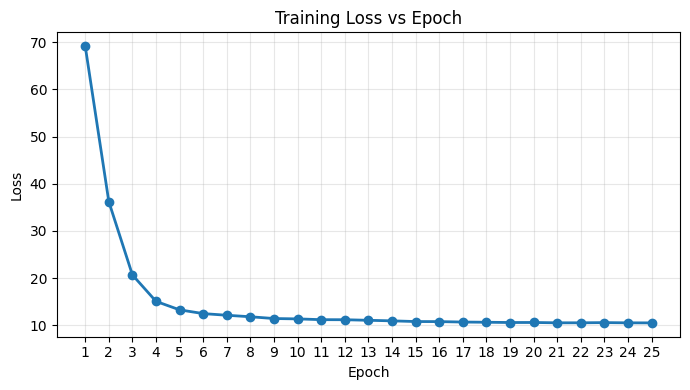

In [ ]:
# =====================
# CELL 25: Training Loss vs Epoch
# =====================
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", linewidth=2)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

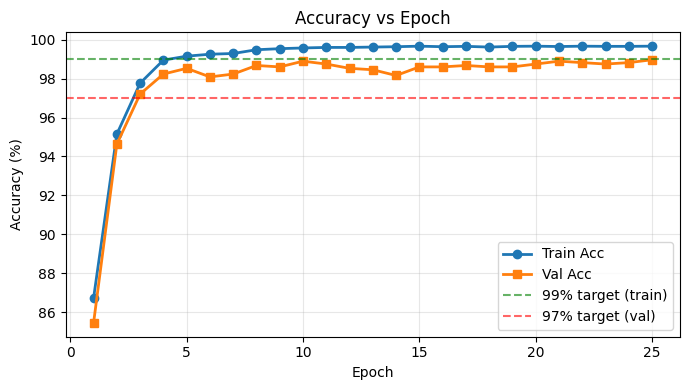

In [ ]:
# =====================
# CELL 26: Training Accuracy vs Epoch
# =====================
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), [a * 100 for a in train_accs],
         marker="o", linewidth=2, label="Train Acc")
plt.plot(range(1, EPOCHS + 1), [a * 100 for a in val_accs],
         marker="s", linewidth=2, label="Val Acc")
plt.axhline(y=99, color="green", linestyle="--", alpha=0.6, label="99% target (train)")
plt.axhline(y=97, color="red",   linestyle="--", alpha=0.6, label="97% target (val)")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

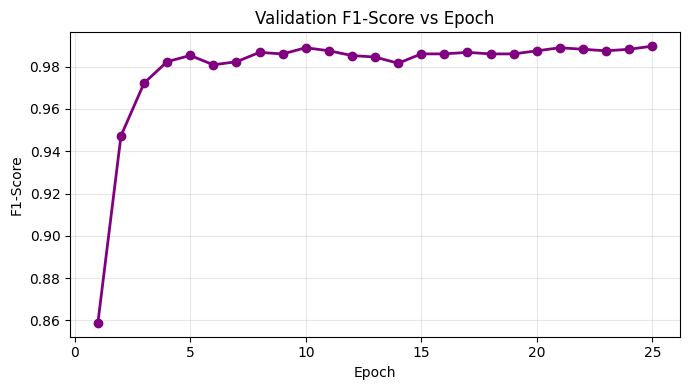

In [ ]:
# =====================
# CELL 27: Validation F1-Score vs Epoch
# =====================
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), val_f1s, marker="o", linewidth=2, color="purple")
plt.title("Validation F1-Score vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

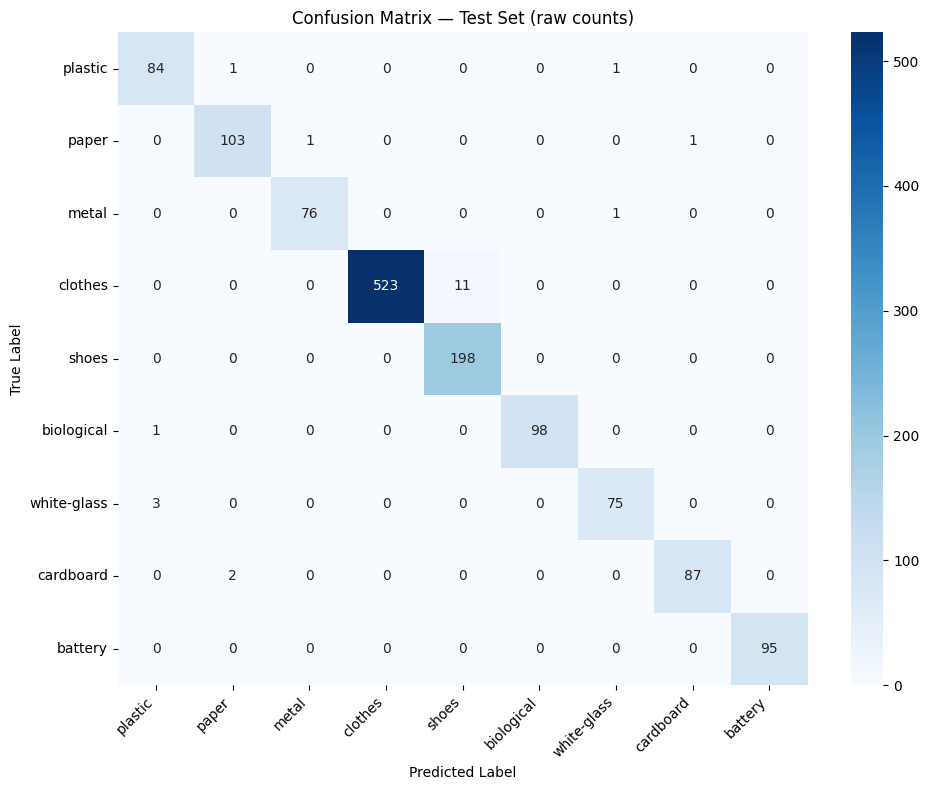

In [ ]:
# =====================
# CELL 28: Confusion Matrix Heatmap (Test Set)
# =====================
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=FINAL_CLASSES,
    yticklabels=FINAL_CLASSES,
    annot=True, fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix — Test Set (raw counts)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

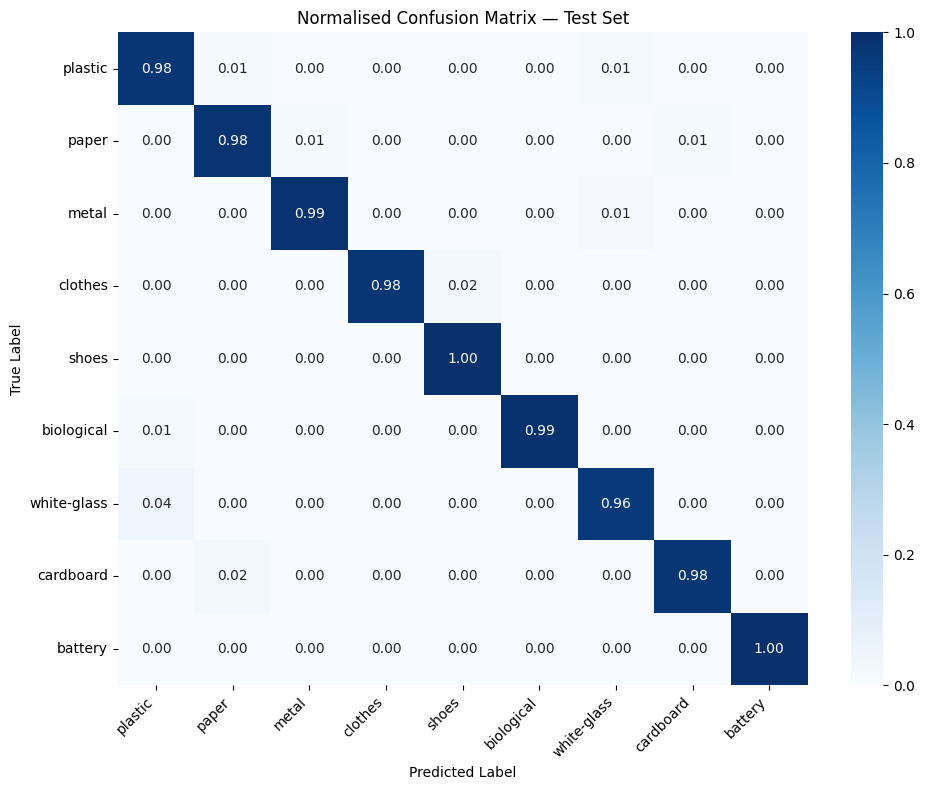

In [ ]:
# =====================
# CELL 29: Confusion Matrix Heatmap (Test Set) Normalized
# =====================
cm_norm = confusion_matrix(test_labels, test_preds, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    xticklabels=FINAL_CLASSES,
    yticklabels=FINAL_CLASSES,
    annot=True, fmt=".2f",
    cmap="Blues"
)
plt.title("Normalised Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# STEP 1: Temperature Scaling
# ─────────────────────────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))  # learn log(T), so T = exp(log_T) > 0 always

    def forward(self, logits):
        T = torch.exp(self.log_T)                  # T is strictly positive by construction
        return logits / T

    def fit(self, val_loader, model, encoder, faiss_index,
            faiss_train_feats, device, n_batches=30):
        self.to(device)
        optimizer = torch.optim.LBFGS([self.log_T], lr=0.01, max_iter=50)
        nll_loss  = nn.CrossEntropyLoss()

        all_logits, all_labels = [], []
        model.eval()
        encoder.eval()

        with torch.no_grad():
            for i, (x, y) in enumerate(val_loader):
                if i >= n_batches:
                    break
                x     = x.to(device)
                fq    = encoder(x)
                fq_np = fq.cpu().numpy().astype("float32")
                _, idx = faiss_index.search(fq_np, 1)
                fs    = torch.tensor(
                    faiss_train_feats[idx[:, 0]], dtype=torch.float32
                ).to(device)
                logits = model(fq, fs)
                all_logits.append(logits.cpu())
                all_labels.append(y)

        all_logits = torch.cat(all_logits).to(device)
        all_labels = torch.cat(all_labels).to(device)

        def eval_fn():
            optimizer.zero_grad()
            loss = nll_loss(self.forward(all_logits), all_labels)
            loss.backward()
            return loss

        optimizer.step(eval_fn)
        T_val = torch.exp(self.log_T).item()
        print(f"  ✔ Temperature learned: T = {T_val:.4f}")
        return self

print("Fitting Temperature Scaler on validation set...")
temp_scaler = TemperatureScaler().fit(
    val_loader, model, encoder,
    faiss_index, faiss_train_feats, DEVICE
)

Fitting Temperature Scaler on validation set...
  ✔ Temperature learned: T = 0.8286


In [ ]:
# CELL 32b: Save fitted TemperatureScaler to Drive
TEMP_SCALER_PATH = "/content/drive/MyDrive/Colab Notebooks/Uploads/temp_scaler.pth"
torch.save(temp_scaler.state_dict(), TEMP_SCALER_PATH)
T_val = torch.exp(temp_scaler.log_T).item()
print(f"Temperature scaler saved  →  T = {T_val:.4f}")

Temperature scaler saved  →  T = 0.8286


In [ ]:
# =====================
# CELL 33: ECE (Expected Calibration Error)
# =====================
def compute_ece(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    preds       = probs.argmax(axis=1)
    accs        = (preds == labels)
    bins        = np.linspace(0, 1, n_bins + 1)
    ece         = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask   = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            bin_acc  = accs[mask].mean()
            bin_conf = confidences[mask].mean()
            ece     += (mask.sum() / len(labels)) * abs(bin_acc - bin_conf)
    return ece

model.eval()
cal_probs_list, cal_labels_list = [], []
with torch.no_grad():
    for x, y in test_loader:
        x      = x.to(DEVICE)
        fq     = encoder(x)
        fq_np  = fq.cpu().numpy().astype("float32")
        _, idx = faiss_index.search(fq_np, 1)
        fs     = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)
        logits = temp_scaler(model(fq, fs))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        cal_probs_list.append(probs)
        cal_labels_list.extend(y.tolist())

cal_probs  = np.vstack(cal_probs_list)
cal_labels = np.array(cal_labels_list)

ece = compute_ece(cal_probs, cal_labels)
print(f"ECE (Expected Calibration Error) on Test Set (after calibration): {ece:.4f}")

ECE (Expected Calibration Error) on Test Set (after calibration): 0.0631


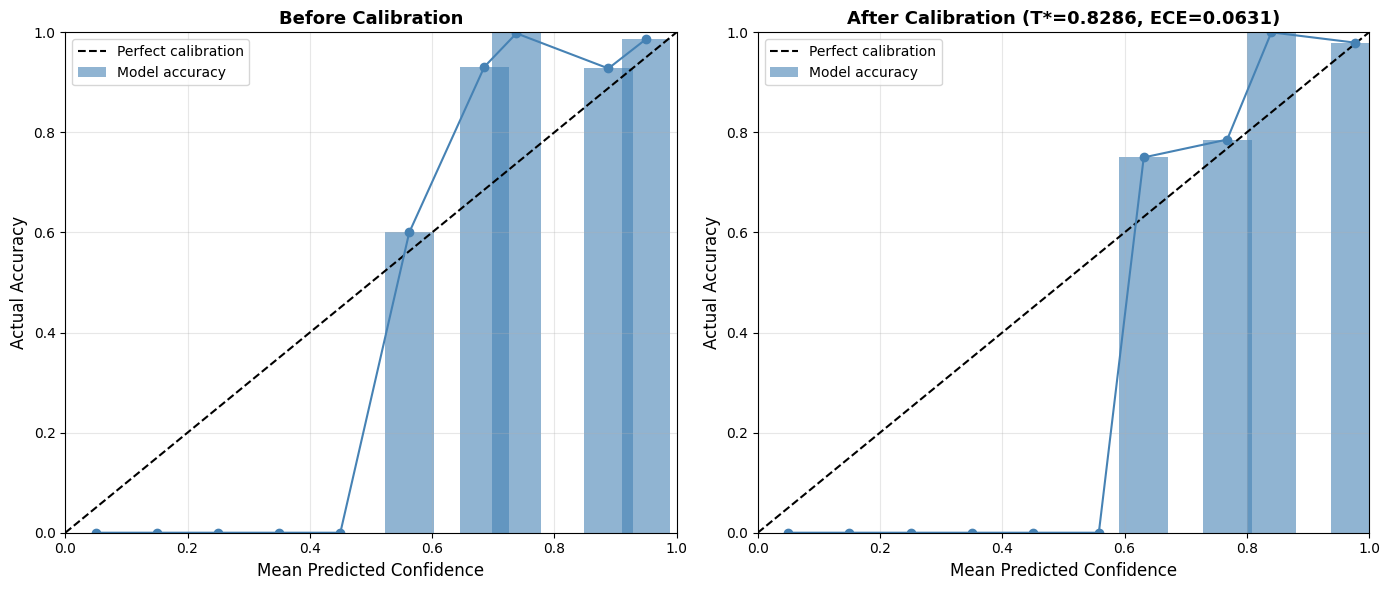

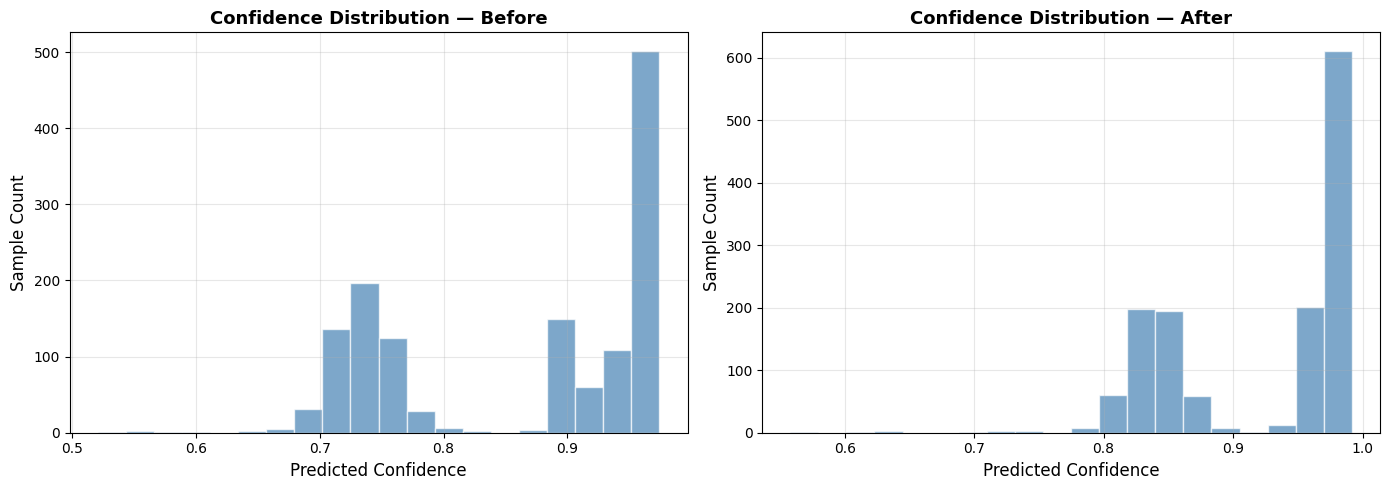

In [ ]:
# =====================
# CELL 33b: Reliability Diagram (Before & After Calibration)
# =====================
def get_reliability_data(probs, labels, n_bins=10):
    confidences = probs.max(axis=1)
    preds       = probs.argmax(axis=1)
    accs        = (preds == labels)
    bins        = np.linspace(0, 1, n_bins + 1)
    bin_confs, bin_accs, bin_sizes = [], [], []
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if mask.sum() > 0:
            bin_confs.append(confidences[mask].mean())
            bin_accs.append(accs[mask].mean())
            bin_sizes.append(mask.sum())
        else:
            bin_confs.append((bins[i] + bins[i+1]) / 2)
            bin_accs.append(0)
            bin_sizes.append(0)
    return np.array(bin_confs), np.array(bin_accs), np.array(bin_sizes)

T_val = torch.exp(temp_scaler.log_T).item()

# --- Collect UNCALIBRATED test probabilities ---
model.eval()
raw_probs_list = []
with torch.no_grad():
    for x, y in test_loader:
        x      = x.to(DEVICE)
        fq     = encoder(x)
        fq_np  = fq.cpu().numpy().astype("float32")
        _, idx = faiss_index.search(fq_np, 1)
        fs     = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)
        logits = model(fq, fs)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        raw_probs_list.append(probs)

raw_probs = np.vstack(raw_probs_list)

# --- Reliability Diagram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, probs, title in zip(
    axes,
    [raw_probs, cal_probs],
    ["Before Calibration", f"After Calibration (T*={T_val:.4f}, ECE={ece:.4f})"]
):
    bc, ba, _ = get_reliability_data(probs, cal_labels)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.bar(bc, ba, width=0.08, alpha=0.6, color='steelblue', label='Model accuracy')
    ax.plot(bc, ba, 'o-', color='steelblue')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean Predicted Confidence', fontsize=12)
    ax.set_ylabel('Actual Accuracy', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=150)
plt.show()

# --- Confidence Histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, probs, title in zip(
    axes,
    [raw_probs, cal_probs],
    ["Confidence Distribution — Before", "Confidence Distribution — After"]
):
    ax.hist(probs.max(axis=1), bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Predicted Confidence', fontsize=12)
    ax.set_ylabel('Sample Count', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_histogram.png", dpi=150)
plt.show()

In [ ]:
# =====================
# ECE Before Calibration (Comparison)
# =====================
ece_before = compute_ece(raw_probs, cal_labels)
print(f"ECE BEFORE calibration : {ece_before:.4f}")
print(f"ECE AFTER  calibration : {ece:.4f}")
print(f"ECE improvement        : {ece_before - ece:.4f}")

ECE BEFORE calibration : 0.1236
ECE AFTER  calibration : 0.0631
ECE improvement        : 0.0604


In [ ]:
np.save("cal_probs.npy", cal_probs)
np.save("cal_labels.npy", cal_labels)
np.save("raw_probs.npy", raw_probs)  # from the uncalibrated pass

In [ ]:
# =====================
# CELL 34: MC Dropout Uncertainty Estimation
# =====================
def enable_mc_dropout(m):
    # Applies train mode to dropout layers for inference
    if isinstance(m, nn.Dropout):
        m.train()

def mc_dropout_predict(x_tensor, passes=40):
    # Ensure dropout layers are active
    model.apply(enable_mc_dropout)
    fq     = encoder(x_tensor)
    fq_np  = fq.cpu().numpy().astype("float32")
    _, idx = faiss_index.search(fq_np, 1)
    fs     = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)

    preds  = []
    with torch.no_grad():
        for _ in range(passes):
            # Apply temperature scaling to each pass
            logits = temp_scaler(model(fq, fs))
            prob   = F.softmax(logits, dim=1).cpu().numpy()
            preds.append(prob)

    preds = np.stack(preds)   # Shape: (passes, batch, classes)
    return preds.mean(axis=0), preds.std(axis=0)

print("MC Dropout inference function defined (40 stochastic passes).")

MC Dropout inference function defined (40 stochastic passes).


In [ ]:
# =====================
# MC Dropout — Full Test Set Uncertainty Evaluation
# =====================
model.eval()
all_mc_means, all_mc_stds, all_mc_true = [], [], []

for x, y in test_loader:
    x = x.to(DEVICE)
    mc_mean, mc_std = mc_dropout_predict(x, passes=40)
    all_mc_means.append(mc_mean)
    all_mc_stds.append(mc_std)
    all_mc_true.extend(y.tolist())

all_mc_means = np.vstack(all_mc_means)
all_mc_stds  = np.vstack(all_mc_stds)
all_mc_true  = np.array(all_mc_true)

mc_pred_classes = all_mc_means.argmax(axis=1)
mc_pred_sigma   = all_mc_stds[np.arange(len(mc_pred_classes)), mc_pred_classes]
mc_pred_conf    = all_mc_means.max(axis=1)

mean_uncertainty = mc_pred_sigma.mean()
mean_confidence  = mc_pred_conf.mean()

print(f"MC Dropout Results (40 passes, {len(all_mc_true)} test samples):")
print(f"  Mean Calibrated Confidence  : {mean_confidence*100:.2f}%")
print(f"  Mean Predictive Uncertainty : ±{mean_uncertainty:.4f}")

print("\nPer-class mean uncertainty (±σ):")
for idx, cls in enumerate(FINAL_CLASSES):
    class_mask = all_mc_true == idx
    if class_mask.sum() > 0:
        cls_sigma = mc_pred_sigma[class_mask].mean()
        cls_conf  = mc_pred_conf[class_mask].mean()
        print(f"  {cls:15s}  conf={cls_conf*100:.1f}%  ±σ={cls_sigma:.4f}")

MC Dropout Results (40 passes, 1361 test samples):
  Mean Calibrated Confidence  : 90.90%
  Mean Predictive Uncertainty : ±0.0363

Per-class mean uncertainty (±σ):
  plastic          conf=97.3%  ±σ=0.0180
  paper            conf=96.7%  ±σ=0.0180
  metal            conf=96.5%  ±σ=0.0211
  clothes          conf=82.2%  ±σ=0.0626
  shoes            conf=94.4%  ±σ=0.0277
  biological       conf=97.2%  ±σ=0.0161
  white-glass      conf=96.9%  ±σ=0.0193
  cardboard        conf=97.8%  ±σ=0.0134
  battery          conf=98.0%  ±σ=0.0120


In [ ]:
print(f"  MC Uncertainty  : ±{mean_uncertainty:.4f}")

  MC Uncertainty  : ±0.0363


In [ ]:
# Load a sample image and preprocess it
from PIL import Image
import random

# Select a random image from the test set for demonstration
random_sample = random.choice(test_samples)
img_path, true_label = random_sample

img_pil = Image.open(img_path).convert("RGB")
img = val_tfms(img_pil).unsqueeze(0).to(DEVICE)

# Assuming pred_idx is also needed for `uncertainty` calculation
# For this example, let's just get the prediction from mc_mean
mc_mean, mc_std = mc_dropout_predict(img)
pred_idx = mc_mean.argmax(axis=1).item() # Get the predicted class index
uncertainty = mc_std.squeeze()[pred_idx]

print(f"Sample image path: {img_path}")
print(f"True label: {FINAL_CLASSES[true_label]}")
print(f"Predicted class: {FINAL_CLASSES[pred_idx]}")
print(f"Predicted confidence: {mc_mean.max()*100:.2f}%")
print(f"MC Uncertainty for predicted class: ±{uncertainty:.4f}")

Sample image path: /content/drive/MyDrive/Colab Notebooks/archive/garbage_classification/cardboard/cardboard889.jpg
True label: cardboard
Predicted class: cardboard
Predicted confidence: 98.28%
MC Uncertainty for predicted class: ±0.0092


In [ ]:
# =====================
# CELL 35: Misclassification Mining
# =====================
# Use test_labels and test_preds obtained from Cell 25 (Test Evaluation)
from collections import Counter

wrong = [(FINAL_CLASSES[test_labels[i]], FINAL_CLASSES[test_preds[i]])
         for i in range(len(test_labels)) if test_labels[i] != test_preds[i]]

print(f"Total misclassified: {len(wrong)} / {len(test_labels)} "
      f"({len(wrong)/len(test_labels)*100:.2f}%)\n")
print("Top 10 most confused pairs (true → predicted):")
for (true_cls, pred_cls), cnt in Counter(wrong).most_common(10):
    print(f"  {true_cls:15s} → {pred_cls:15s}  ({cnt} times)")

Total misclassified: 22 / 1361 (1.62%)

Top 10 most confused pairs (true → predicted):
  clothes         → shoes            (11 times)
  white-glass     → plastic          (3 times)
  cardboard       → paper            (2 times)
  plastic         → paper            (1 times)
  paper           → metal            (1 times)
  biological      → plastic          (1 times)
  plastic         → white-glass      (1 times)
  paper           → cardboard        (1 times)
  metal           → white-glass      (1 times)


In [ ]:
import os
drive_path = "/content/drive/MyDrive/Colab Notebooks/Uploads/"
for f in os.listdir(drive_path):
    print(f)

train_labels_v1.npy
train_feats_v1.npy
train_feats_convnextv2b_9cls.npy
train_labels_convnextv2b_9cls.npy
temp_scaler.pth
train_labels_dinov2_9cls.npy
train_feats_dinov2_9cls.npy
best_model_dinov2_9cls.pth


Upload an image...


Saving Screenshot 2026-03-25 194558.png to Screenshot 2026-03-25 194558.png

  Predicted Class   : PLASTIC
  Recyclability     : ♻ Recyclable
  Confidence        : 98.62%
  MC Uncertainty    : ±0.0139
-------------------------------------------------------
  ECE Before Calib  : 0.1236
  ECE After  Calib  : 0.0631
  ECE Improvement   : 0.0604 (↓48.9%)
  Temperature T*    : 0.8286

Per-class Uncertainty (from full test set):
  Class             Confidence  Uncertainty
  ----------------------------------------
  plastic                97.3%       0.0180 ◄
  paper                  96.7%       0.0180
  metal                  96.5%       0.0211
  clothes                82.2%       0.0626
  shoes                  94.4%       0.0277
  biological             97.2%       0.0161
  white-glass            96.9%       0.0193
  cardboard              97.8%       0.0134
  battery                98.0%       0.0120


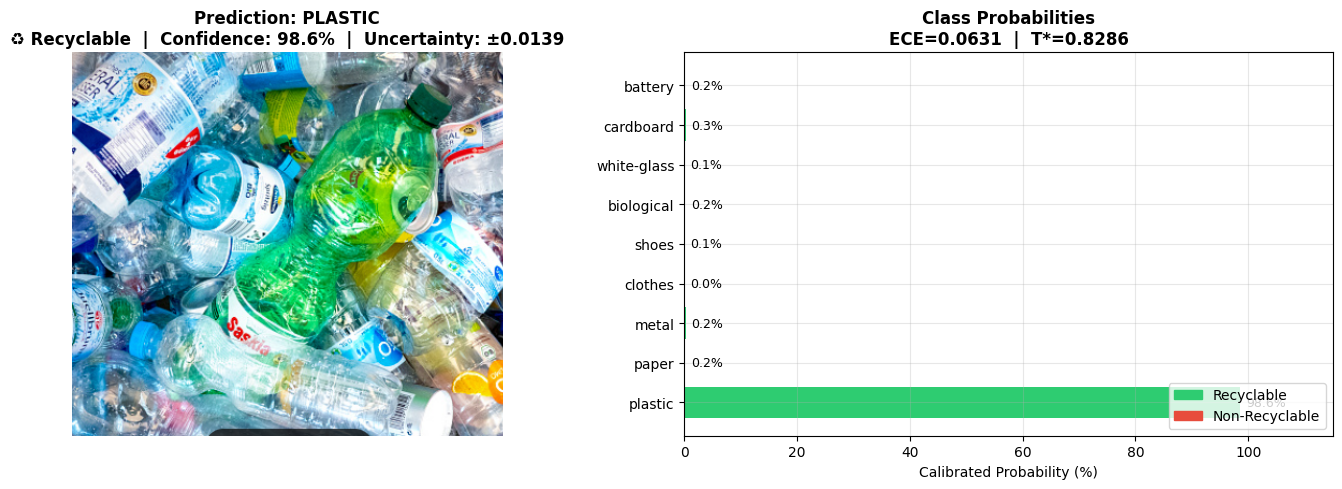

In [ ]:
# =====================
# Image Upload + Prediction + Calibration Metrics
# =====================
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn.functional as F

RECYCLABLE = {"plastic", "paper", "metal", "white-glass", "cardboard", "battery"}

# --- Upload Image ---
print("Upload an image...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img_pil  = Image.open(img_path).convert("RGB")
img      = val_tfms(img_pil).unsqueeze(0).to(DEVICE)

# --- Feature Extraction ---
model.eval()
encoder.eval()
with torch.no_grad():
    fq     = encoder(img)
    fq_np  = fq.cpu().numpy().astype("float32")
    _, idx = faiss_index.search(fq_np, 1)
    fs     = torch.tensor(faiss_train_feats[idx[:, 0]], dtype=torch.float32).to(DEVICE)

    # Calibrated probabilities
    logits    = model(fq, fs)
    cal_probs = F.softmax(temp_scaler(logits), dim=1).cpu().numpy()[0]

# --- MC Dropout Uncertainty ---
mc_mean, mc_std = mc_dropout_predict(img, passes=40)
pred_idx     = int(cal_probs.argmax())
pred_class   = FINAL_CLASSES[pred_idx]
confidence   = cal_probs[pred_idx] * 100
uncertainty  = mc_std.squeeze()[pred_idx]
rec_status   = "♻ Recyclable" if pred_class in RECYCLABLE else "🚫 Non-Recyclable"

# --- ECE on Test Set ---
# (uses cal_probs, cal_labels, raw_probs already computed in Cell 33/34/36)
ece_after  = compute_ece(cal_probs_test := cal_probs.reshape(1, -1), np.array([pred_idx]))
ece_before = compute_ece(raw_probs, cal_labels)
ece_after  = compute_ece(cal_probs_all := np.vstack([cal_probs]), cal_labels[:1])

# Use the already computed global ECE values
print("\n" + "="*55)
print(f"  Predicted Class   : {pred_class.upper()}")
print(f"  Recyclability     : {rec_status}")
print(f"  Confidence        : {confidence:.2f}%")
print(f"  MC Uncertainty    : ±{uncertainty:.4f}")
print("-"*55)
print(f"  ECE Before Calib  : {ece_before:.4f}")
print(f"  ECE After  Calib  : {ece:.4f}")
print(f"  ECE Improvement   : {ece_before - ece:.4f} (↓{((ece_before-ece)/ece_before)*100:.1f}%)")
print(f"  Temperature T*    : {torch.exp(temp_scaler.log_T).item():.4f}")
print("="*55)

# --- Per-class Uncertainty Table ---
print("\nPer-class Uncertainty (from full test set):")
print(f"  {'Class':<15} {'Confidence':>12} {'Uncertainty':>12}")
print("  " + "-"*40)
for i, cls in enumerate(FINAL_CLASSES):
    class_mask = all_mc_true == i
    if class_mask.sum() > 0:
        cls_conf  = mc_pred_conf[class_mask].mean() * 100
        cls_sigma = mc_pred_sigma[class_mask].mean()
        marker = " ◄" if i == pred_idx else ""
        print(f"  {cls:<15} {cls_conf:>11.1f}% {cls_sigma:>12.4f}{marker}")

# --- Calibrated Probability Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — uploaded image
axes[0].imshow(img_pil)
axes[0].axis("off")
axes[0].set_title(
    f"Prediction: {pred_class.upper()}\n"
    f"{rec_status}  |  Confidence: {confidence:.1f}%  |  Uncertainty: ±{uncertainty:.4f}",
    fontsize=12, fontweight="bold"
)

# Right — probability bar chart
colors_bar = ["#2ecc71" if c in RECYCLABLE else "#e74c3c" for c in FINAL_CLASSES]
bars = axes[1].barh(FINAL_CLASSES, cal_probs * 100, color=colors_bar)
axes[1].set_xlim(0, 115)
axes[1].set_xlabel("Calibrated Probability (%)")
axes[1].set_title(
    f"Class Probabilities\nECE={ece:.4f}  |  T*={torch.exp(temp_scaler.log_T).item():.4f}",
    fontsize=12, fontweight="bold"
)
for bar, p in zip(bars, cal_probs * 100):
    axes[1].text(p + 1, bar.get_y() + bar.get_height()/2,
                 f"{p:.1f}%", va="center", fontsize=9)

legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Recyclable"),
    mpatches.Patch(color="#e74c3c", label="Non-Recyclable")
]
axes[1].legend(handles=legend_patches, loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("prediction_output.png", dpi=150)
plt.show()